## 개발자연봉 데이터 활용 데이터분석 및 시각화
- 개발자 스킬, 연차, 성별, 지역별로 데이터 분석하기

In [2]:
#read_csv함수 활용하여 파일 데이터프레임 불러오기
#"일련번호"열을 인덱스로 만들기
#인코딩 ->'euc-kr

In [3]:
import chardet
with open('data/Developer Salary.csv', 'rb') as f:
    d = f.read()
chardet.detect(d) #내가 열려고 하는 파일이 뭘로 인코딩 되어있는 파일인지 확인하기위함

{'encoding': 'EUC-KR', 'confidence': 0.99, 'language': 'Korean'}

In [4]:
import pandas as pd

data = pd.read_csv("data/Developer Salary.csv", encoding='euc-kr', index_col='일련번호')
data

,나이,학력,성별,정신건강,전문직,개발공부기간,연차,국적,연봉,보유기술개수
일련번호,,,,,,,,,,
DEV1,<35,Master,Man,No,Dev,15,6,Germany,77290,7
DEV2,<35,Undergraduate,Man,No,Dev,9,6,Canada,46135,13
DEV3,>35,Master,Man,No,Dev,26,18,Germany,77831,17
DEV4,>35,Undergraduate,Man,No,Dev,39,21,United Kingdom of Great Britain and Northern I...,68507,3
DEV5,<35,Master,Man,No,Dev,19,10,Germany,60535,5
...,...,...,...,...,...,...,...,...,...,...
DEV33462,<35,Master,Man,Yes,Dev,7,5,United States of America,94000,5
DEV33463,<35,Undergraduate,Man,No,Dev,7,2,Germany,41058,13
DEV33464,>35,Undergraduate,Man,No,Dev,21,16,United States of America,115000,11


 **데이터 살펴보기**


 * 일련번호
 * 나이 (<35, >35) : 35세 미만 or 35세 이상
 * 학력 (Undergraduate : 학사, Master : 석사, phD : 박사, NoHigherEd : 고등학교 졸업, Other : 그 외)
 * 성별 (Man, Woman, NonBinary) : 남자, 여자, 제 3의 성
 * 정신건강 (Yes : 건강, No : 병력있음)
 * 전문직 : 전문개발자가 맞는지 (삭제예정)
 * 개발공부기간 : 코딩을 공부한 기간(수치형)
 * 연차 : 개발자로써 일을 한 기간(수치형)
 * 국적 : 독일, 캐나다, 영국, 미국, 인도, 일본, 한국
 * 연봉 : 1년간 받는 급여(달러)
 * 보유기술개수 : 해당 사람이 다룰 수 있는 기술의 개수(수치형)

In [5]:
# 데이터 연산
# 1. 연봉데이터를 활용해서 월급 컬럼을 추가(연봉/12)
# 2. 달러로  저장되어있는 데이터를 원화로 환산(환율 1506)

data['월급'] = data['연봉'] / 12 * 1506


In [6]:
data

,나이,학력,성별,정신건강,전문직,개발공부기간,연차,국적,연봉,보유기술개수,월급
일련번호,,,,,,,,,,,
DEV1,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9699895.0
DEV2,<35,Undergraduate,Man,No,Dev,9,6,Canada,46135,13,5789942.5
DEV3,>35,Master,Man,No,Dev,26,18,Germany,77831,17,9767790.5
DEV4,>35,Undergraduate,Man,No,Dev,39,21,United Kingdom of Great Britain and Northern I...,68507,3,8597628.5
DEV5,<35,Master,Man,No,Dev,19,10,Germany,60535,5,7597142.5
...,...,...,...,...,...,...,...,...,...,...,...
DEV33462,<35,Master,Man,Yes,Dev,7,5,United States of America,94000,5,11797000.0
DEV33463,<35,Undergraduate,Man,No,Dev,7,2,Germany,41058,13,5152779.0
DEV33464,>35,Undergraduate,Man,No,Dev,21,16,United States of America,115000,11,14432500.0


In [7]:
#기술통계 확인하기 -> describe()
data.describe()

,개발공부기간,연차,연봉,보유기술개수,월급
count,33466.000000,33466.000000,33466.000000,33466.000000,3.346600e+04
mean,15.160103,9.765523,89023.017988,13.230025,1.117239e+07
std,10.092218,8.609730,53306.941978,6.840151,6.690021e+06
min,0.000000,0.000000,1.000000,0.000000,1.255000e+02
25%,8.000000,4.000000,50000.000000,8.000000,6.275000e+06
50%,12.000000,7.000000,82890.000000,12.000000,1.040270e+07
75%,20.000000,14.000000,125639.000000,17.000000,1.576769e+07
max,50.000000,50.000000,224000.000000,105.000000,2.811200e+07


In [8]:
data.describe(include='object')

,나이,학력,성별,정신건강,전문직,국적
count,33466,33466,33466,33466,33466,33466
unique,2,5,3,2,2,7
top,<35,Undergraduate,Man,No,Dev,United States of America
freq,20746,19232,30848,24532,30588,14696


In [9]:
# 개발자의 남녀 비율 확인
# 고유한 데이터의 개수를 확인하는 함수 -> value_counts()
data["성별"].value_counts()

성별
Man          30848
Woman         1870
NonBinary      748
Name: count, dtype: int64

In [10]:
#개발자 전체 평균 월근 계산 -> mean()
data["월급"].mean()

np.float64(11172388.75754497)

In [11]:
#한국의 개발자 평균 월급 계산하기
# 1. 한국은 데이터 내에서 어떤 이름으로 표기되어있는 지 확인하기
data["국적"].unique()
# 2. 불리언 인덱싱하기
korea_developer = data[data["국적"] == "South Korea"]
# 3. 월급의 평균 구하기
korea_developer["월급"].mean()

np.float64(5958262.402777778)

In [12]:
#국적, 월급 컬럼을 인덱싱해서 데이터프레임으로 가져오기 -> [[]]
country_pay = data[["국적", "월급"]]
country_pay

,국적,월급
일련번호,,
DEV1,Germany,9699895.0
DEV2,Canada,5789942.5
DEV3,Germany,9767790.5
DEV4,United Kingdom of Great Britain and Northern I...,8597628.5
DEV5,Germany,7597142.5
...,...,...
DEV33462,United States of America,11797000.0
DEV33463,Germany,5152779.0
DEV33464,United States of America,14432500.0


In [13]:
#groupby() -> 기준이 되는 컬럼을 지정해서 그 기준에 맞게 그룹을 지어주는 함수
country_pay.groupby(by = "국적").get_group("United States of America")

,국적,월급
일련번호,,
DEV6,United States of America,12926500.0
DEV10,United States of America,13177500.0
DEV13,United States of America,12550000.0
DEV18,United States of America,17570000.0
DEV19,United States of America,6777000.0
...,...,...
DEV33459,United States of America,15060000.0
DEV33461,United States of America,14432500.0
DEV33462,United States of America,11797000.0


In [14]:
country_pay_mean = country_pay.groupby("국적").mean().astype(int)

In [15]:
import pandas as pd
f_data = pd.DataFrame({'과일': ['사과', '바나나', '사과', '바나나', '사과'],
                       '가격': [1000, 2000, 1500, 2200, 1300]})
f_data

,과일,가격
0,사과,1000
1,바나나,2000
2,사과,1500
3,바나나,2200
4,사과,1300


In [16]:
#사과, 바나나 각각의 평균 가격 구하기
#apple_avg = f_data[f_data["과일"] == "사과"]["가격"].mean()
#banana_avg = f_data[f_data["과일"] == "바나나"]["가격"].mean()

#groupby이용

f_data.groupby("과일").mean()

,가격
과일,
바나나,2100.000000
사과,1266.666667


In [17]:
#사고 , 바나나의 데이터가 각각 몇개있는지 구하기
f_data["과일"].value_counts()

과일
사과     3
바나나    2
Name: count, dtype: int64

### 시각화


In [18]:
import matplotlib.pyplot as plt

In [19]:
print(country_pay_mean)

                                                          월급
국적                                                          
Canada                                              10837279
Germany                                              8769293
India                                                3039277
Japan                                                8189965
South Korea                                          5958262
United Kingdom of Great Britain and Northern Ir...  10180187
United States of America                            15533889


In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. 폰트 설정 (Windows 기준 'Malgun Gothic', Mac 기준 'AppleGothic')
plt.rc('font', family='Malgun Gothic')

<function matplotlib.pyplot.show(close=None, block=None)>

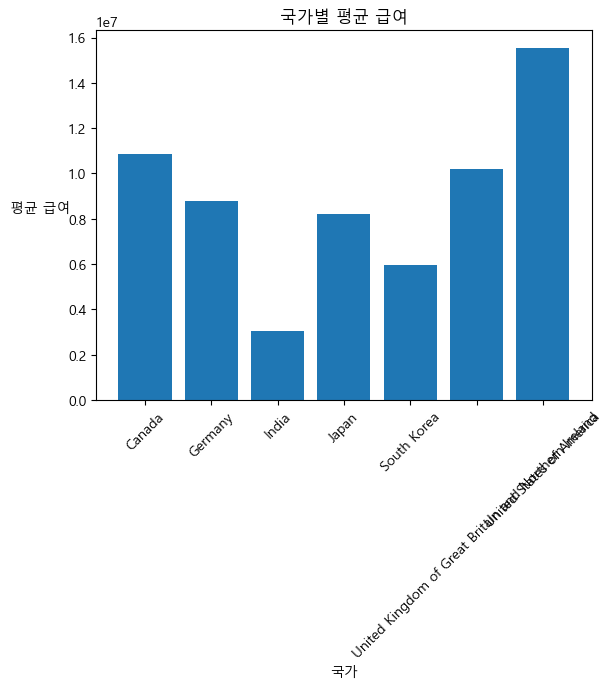

In [21]:
# 수직 막대 그래프 생성 (bar 사용)
x = country_pay_mean.index
y= country_pay_mean["월급"]

plt.bar(x, y)
# 축 라벨 및 제목 설정
plt.xlabel('국가')
plt.ylabel('평균 급여', rotation=0, labelpad=20)
plt.title('국가별 평균 급여')
plt.xticks(rotation=45)

plt.show

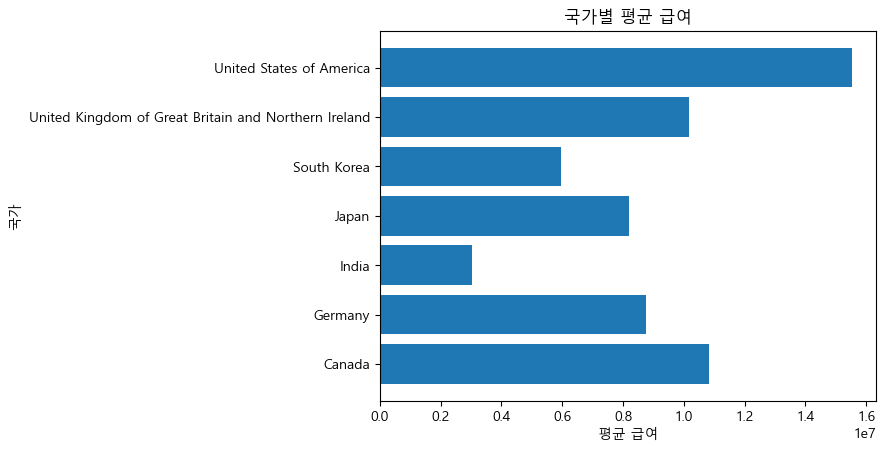

In [22]:

# 수평 막대 그래프 생성
plt.barh(country_pay_mean.index, country_pay_mean["월급"])

# 제목 및 라벨 설정
plt.title('국가별 평균 급여')
plt.xlabel('평균 급여')
plt.ylabel('국가')

plt.show()

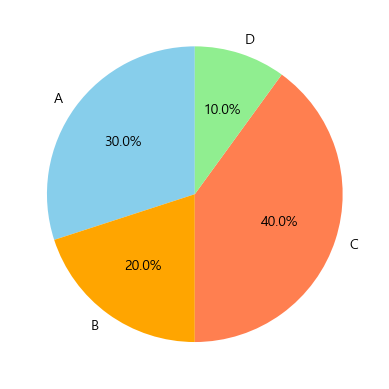

In [23]:
lab = ["A", "B", "C", "D"]
size = [30,20,40,10]
col = ["skyblue", "orange", "coral", "lightgreen"]

plt.pie(size, labels=lab, colors=col, autopct='%1.1f%%', startangle=90)
plt.show()

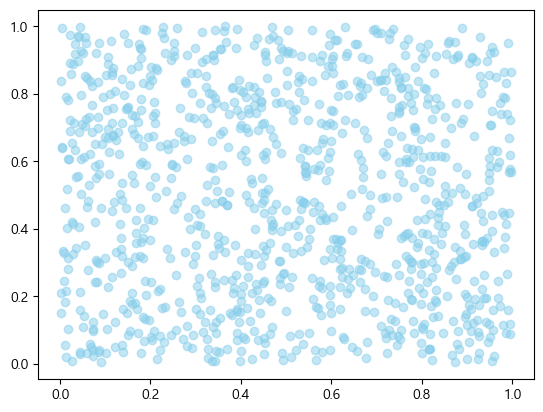

In [24]:
#산점도 그래프 그리는 방법
import numpy as np

x = np.random.rand(1000)
y = np.random.rand(1000)

plt.scatter(x, y, color='skyblue', alpha=0.5)  # alpha -> 투명도 표시
plt.show()

In [25]:
#colormap 속성
# 1.연속형(colormap for continuous data): 연속적인 값에 대해 색상을 지정할 때 사용
# viridis: 퍼지는 색상(보라색 → 노란색), 기본
# plasma: 뜨거운 색상(보라색 → 빨강, 노랑)
# inferno: 더 뜨거운 색상(검정 → 빨강 → 노랑)
# magma: 차가운 색상(검정 → 보라 → 노랑)
# cividis: 시각 장애인을 고려한 색상
# twilight: 흰색과 파란색을 강조하는 색상
# copper: 주로 금속 계열의 색상(갈색 → 금색)
# coolwarm: 파란색에서 빨간색으로 가는 그라데이션
# YlGnBu: 노랑 → 초록 → 파랑 그라데이션
# RdYlBu: 빨강 → 노랑 → 파랑 그라데이션

# 2.범주형(colormap for categorical data): 데이터가 범주형일 때 사용할 수 있는 색상
# Set1, Set2, Set3: 범주형 색상 중에서 자주 사용되는 컬러셋.
# Pastel1, Pastel2: 부드러운 색상셋.
# Paired: 다양한 색이 조화를 이루는 색상셋.
# Dark2: 더 어두운 색상셋.
# Accent: 다채로운 색상셋.

# 3.기타 범주형 색상:
# tab10: 10가지 색상으로 구성된 색상 셋.
# tab20: 20가지 색상으로 구성된 색상 셋.
# Set1: 파스텔 계열의 색상 셋.
# rainbow: 무지개 색상(빨강 → 보라)
# spring: 분홍색에서 노란색으로 변하는 색상.
# summer: 녹색에서 노란색으로 변하는 색상.
# autumn: 빨간색에서 노란색으로 변하는 색상.
# winter: 파란색에서 초록색으로 변하는 색상.

<Axes: ylabel='학력'>

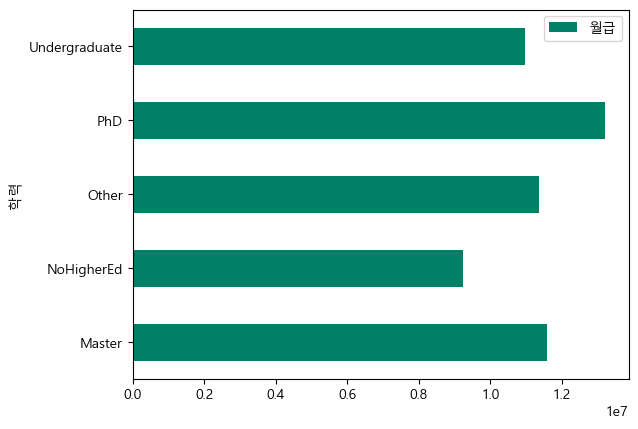

In [26]:
#학력별 평균월급비교
#1. 학력과 월급 컬럼 인덱싱
grade_pay = data[["학력", "월급"]]
#2. 학력을 기준으로 groupby, mean 월급의 평균을 구하기
grade_avg = grade_pay.groupby("학력").mean().astype(int)
grade_avg
'''
plt.bar(grade_avg.index, grade_avg["월급"])
plt.xticks(rotation=90)
plt.title('학력별 평균 월급')
plt.xlabel('학력')
plt.ylabel('평균 월급')
plt.show()
'''
grade_avg.plot(kind='barh', colormap='summer')


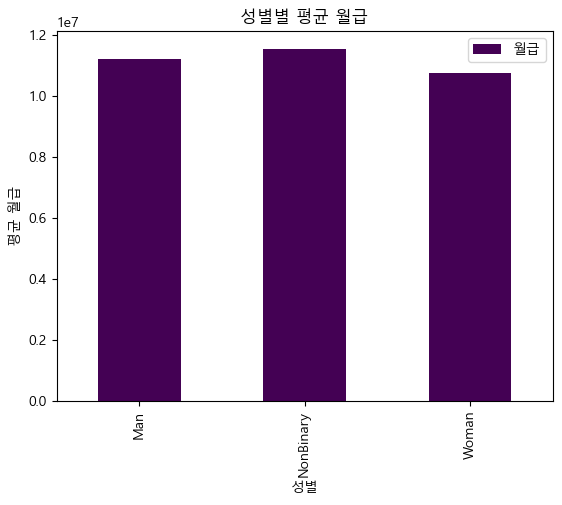

In [27]:
#성별 평균월급 비교
sex_pay = data[["성별", "월급"]]
sex_avg = sex_pay.groupby("성별").mean()
'''
plt.bar(sex_avg.index, sex_avg["월급"])
plt.title('성별별 평균 월급')
plt.xlabel('성별')
plt.ylabel('평균 월급')
'''
sex_avg.plot(kind='bar', title='성별별 평균 월급', xlabel='성별', ylabel='평균 월급',colormap='viridis')
plt.show()

<Axes: title={'center': '학력별인원'}, ylabel='count'>

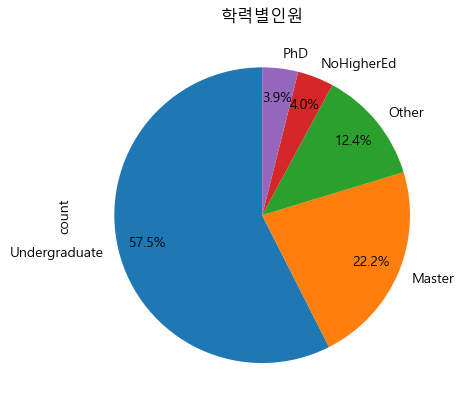

In [28]:
data["학력"].value_counts().plot(kind="pie", startangle=90, autopct="%1.1f%%",
                                    title = "학력별인원", pctdistance=0.8)

### 멀티 인덱스


In [29]:
#성별 -> 학력 -> 평균월급
#예) 여성인데 박사학위를 가지고있는 사람들의 평균 월급은?
sex_grade = data[["성별", "학력", "월급"]].groupby(["성별", "학력"]).mean().astype(int)
sex_grade

월급
성별        학력                     
Man       Master         11594187
          NoHigherEd      9304338
          Other          11419416
          PhD            13368516
          Undergraduate  10965101
NonBinary Master         12194974
          NoHigherEd      8276053
          Other          10473427
          PhD            11649575
          Undergraduate  11985723
Woman     Master         11256776
          NoHigherEd      8583597
          Other          10344248
          PhD            11467063
          Undergraduate  10659376

### seaborn 라이브러리
- 파이썬의 데이터 시각화 라이브러리, 특히 통계적 그래프 쉽게 그릴 수 있다.
- matplotlib을 기반으로 하지만 좀 더 편하게 시각화 가능

In [30]:
import seaborn as sns

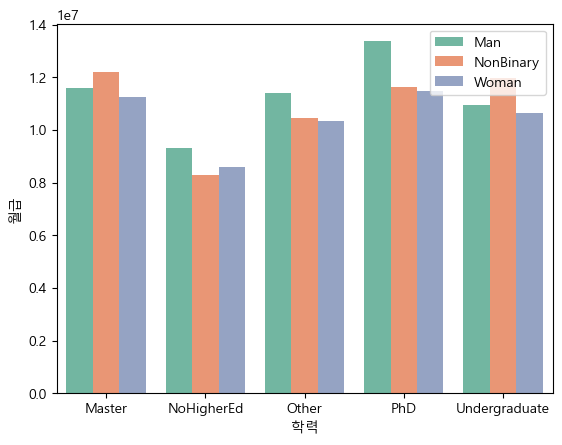

In [31]:
sns.barplot(data = sex_grade, x = "학력", hue="성별", y="월급", palette="Set2")
plt.legend(loc="upper right")

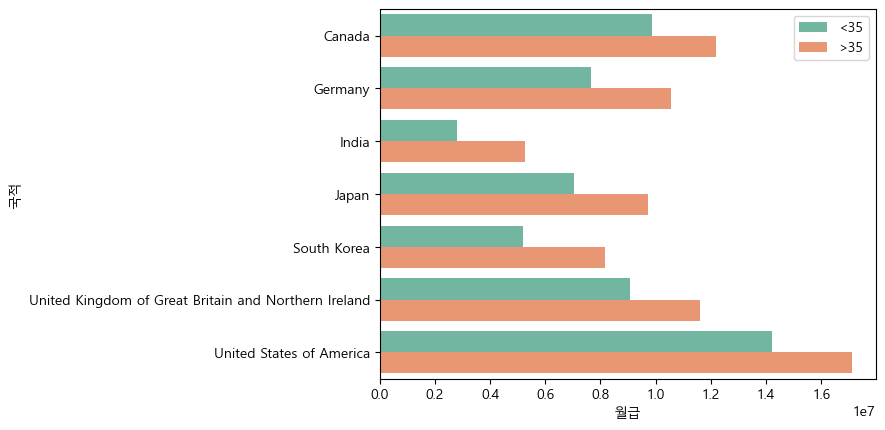

In [32]:
#나이와 국적을 기준으로 평균 월급 비교
age_nation = data[["나이", "국적", "월급"]].groupby(["나이", "국적"]).mean().astype(int)

sns.barplot(data = age_nation, x = "월급", hue="나이", y="국적", palette="Set2")
plt.legend(loc="upper right")
plt.show()

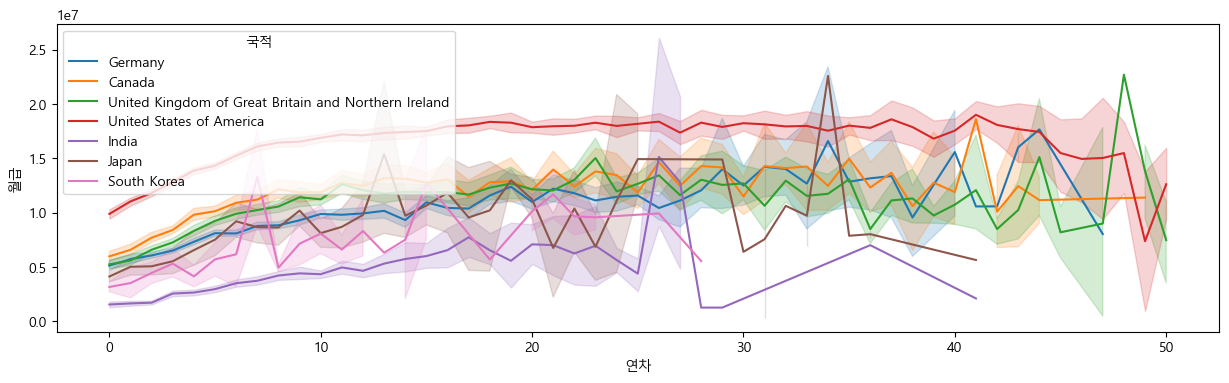

In [33]:
#seaborn 라이브러리로 선 그래프 활용하기
#선 뒤에있는 음영 -> 신뢰구간 -> 오차범위
plt.figure(figsize=(15,4))
sns.lineplot(data = data, x="연차", hue="국적", y="월급")
plt.show()

In [48]:
#국적, 학력 ,월급 -> 최소, 최대, 평균 , 중앙값의 월급이 궁금하다면?
group = data.groupby(["국적", "학력"])["월급"].agg(["min", "max", "mean", "median", "std"])
group

min  \
국적                                                 학력                         
Canada                                             Master            9914.5   
                                                   NoHigherEd      911130.0   
                                                   Other            13052.0   
                                                   PhD            3986507.5   
                                                   Undergraduate    12801.0   
Germany                                            Master            8785.0   
                                                   NoHigherEd       13554.0   
                                                   Other           129516.0   
                                                   PhD               9412.5   
                                                   Undergraduate    10165.5   
India                                              Master             125.5   
                                                   NoHigherEd       63252.0   
                                                   Other             1506.0   
                                                   PhD             841101.0   
                                                   Undergraduate      878.5   
Japan                                              Master            1004.0   
                                                   NoHigherEd     2234904.0   
                                                   Other              627.5   
                                                   PhD             551196.0   
                                                   Undergraduate      376.5   
South Korea                                        Master            3012.0   
                                                   NoHigherEd         376.5   
                                                   Other          2980123.0   
                                                   PhD            5260834.5   
                                                   Undergraduate      502.0   
United Kingdom of Great Britain and Northern Ir... Master            8659.5   
                                                   NoHigherEd      390054.0   
                                                   Other             2635.5   
                                                   PhD             486689.0   
                                                   Undergraduate     5020.0   
United States of America                           Master             125.5   
                                                   NoHigherEd       12550.0   
                                                   Other             4518.0   
                                                   PhD              22213.5   
                                                   Undergraduate      125.5   

                                                                         max  \
국적                                                 학력                          
Canada                                             Master         26458788.5   
                                                   NoHigherEd     23729289.0   
                                                   Other          26948740.5   
                                                   PhD            26576884.0   
                                                   Undergraduate  27928770.0   
Germany                                            Master         27675762.0   
                                                   NoHigherEd     27302901.5   
                                                   Other          27132598.0   
                                                   PhD            27132598.0   
                                                   Undergraduate  28105976.0   
India                                              Master         27861000.0   
                                                   NoHigherEd      8740824.0   
                            

In [35]:
#한국인 중 master급의 평균 월급은?
group.loc[("South Korea", "Master"), "mean"]

np.float64(6618051.925925926)

### 개발자별 보유 스킬 데이터 다뤼

In [36]:
#데이터 불러오기 -> read_csv(), encoding='euc-kr', '일련번호 인덱스로 설정
skills = pd.read_csv("data/Developer Skills.csv", encoding='euc-kr', index_col="일련번호")
skills

,보유기술
일련번호,
DEV1,C;C++;Java;Perl;Ruby;Git;Ruby on Rails
DEV2,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...
DEV3,C++;HTML/CSS;Java;JavaScript;Kotlin;Node.js;Ty...
DEV4,Python;Git;PostgreSQL
DEV5,C;C++;Java;Python;Git
...,...
DEV33462,C;C#;C++;Microsoft Azure;SQLite
DEV33463,C#;HTML/CSS;JavaScript;TypeScript;Docker;Kuber...
DEV33464,C#;HTML/CSS;Java;JavaScript;npm;ASP.NET Core ;...


In [37]:
# 보유 기술의 내용은 세미클론으로 구분되어 있다
# 문자열 함수인 split()을 통해서 분리하겟다
skill_data = skills["보유기술"].str.split(";")

In [38]:
# explode() -> 리스트 형태의 데이터를 다수의 형으로 전개한느 기능을 제공
# 리스트 안의 요소만큼 형이 증식

explode_skill = skill_data.explode()

In [39]:
skills.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33466 entries, DEV1 to DEV33466
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   보유기술    33438 non-null  object
dtypes: object(1)
memory usage: 522.9+ KB


In [40]:
#결측치 있는지 확인
explode_skill.isnull().sum()
#28개의 결측치 확인
# 개발자 연봉 데이터와 병합한후 어떤 데이터가 결측치인지 확인

np.int64(28)

### 데이터병합
- concat(), merge()
- 공통된 컬럼을 기준으로 양쪽 데이터를 병합하기 위해 merge() 함수사용
- merge(a,b,how= , on=)
- how: inner, outer, left, right, full
- on: 어떤 컬럼의 기준으로 병합할지 결정

In [41]:
full_data = data = pd.merge(explode_skill, data,on="일련번호", how="inner")
full_data

,보유기술,나이,학력,성별,정신건강,전문직,개발공부기간,연차,국적,연봉,보유기술개수,월급
일련번호,,,,,,,,,,,,
DEV1,C,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9699895.0
DEV1,C++,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9699895.0
DEV1,Java,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9699895.0
DEV1,Perl,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9699895.0
DEV1,Ruby,<35,Master,Man,No,Dev,15,6,Germany,77290,7,9699895.0
...,...,...,...,...,...,...,...,...,...,...,...,...
DEV33465,DynamoDB,<35,Undergraduate,Man,Yes,Dev,5,1,United States of America,70000,15,8785000.0
DEV33465,Microsoft SQL Server,<35,Undergraduate,Man,Yes,Dev,5,1,United States of America,70000,15,8785000.0
DEV33465,SQLite,<35,Undergraduate,Man,Yes,Dev,5,1,United States of America,70000,15,8785000.0


In [42]:
full_data.isnull().sum()

보유기술      28
나이         0
학력         0
성별         0
정신건강       0
전문직        0
개발공부기간     0
연차         0
국적         0
연봉         0
보유기술개수     0
월급         0
dtype: int64

In [43]:
#full_data에서 어떤값이 결측치인지
full_data[full_data['보유기술'].isnull()]
#결측치를 없음 문자열로 채우자
full_data['보유기술'] = full_data['보유기술'].fillna('없음')
#재검색
full_data[full_data['보유기술'].isnull()]

,보유기술,나이,학력,성별,정신건강,전문직,개발공부기간,연차,국적,연봉,보유기술개수,월급
일련번호,,,,,,,,,,,,


In [44]:
# unique 함수 활용하여 보유기술 컬럼에 어떤 데이터 들이 있는지 확인
full_data['보유기술'].unique()

array(['C', 'C++', 'Java', 'Perl', 'Ruby', 'Git', 'Ruby on Rails',
       'Bash/Shell', 'HTML/CSS', 'JavaScript', 'PHP', 'SQL', 'jQuery',
       'Laravel', 'AWS', 'MySQL', 'PostgreSQL', 'Kotlin', 'Node.js',
       'TypeScript', 'Docker', 'Kubernetes', 'Angular', 'Express',
       'Spring', 'Heroku', 'DynamoDB', 'Python', 'Assembly', 'Rust',
       'Ansible', 'Terraform', 'Yarn', 'React.js', 'SQLite', 'C#', 'VBA',
       'ASP.NET', 'Microsoft SQL Server', 'Gatsby', 'R', 'Flask',
       'ASP.NET Core ', 'Microsoft Azure', 'Elasticsearch', 'Julia',
       'Matlab', 'Google Cloud Platform', 'Clojure', 'Go', 'Angular.js',
       'MariaDB', 'MongoDB', 'Dart', 'PowerShell', 'Xamarin', 'Couchbase',
       'Redis', 'Vue.js', 'Chef', 'Unity 3D', 'Django', 'F#', 'Scala',
       'Unreal Engine', 'FastAPI', 'Firebase', 'DigitalOcean',
       'Objective-C', 'Swift', 'Symfony', 'IBM Cloud or Watson', 'Oracle',
       'Groovy', 'IBM DB2', 'Puppet', 'Cassandra', 'LISP', 'Delphi',
       'APL', 'Erlang'

In [45]:
#국내 개발자 데이터만 활용해보자!
korea_dev = full_data[full_data["국적"] == "South Korea"]

<Axes: ylabel='보유기술'>

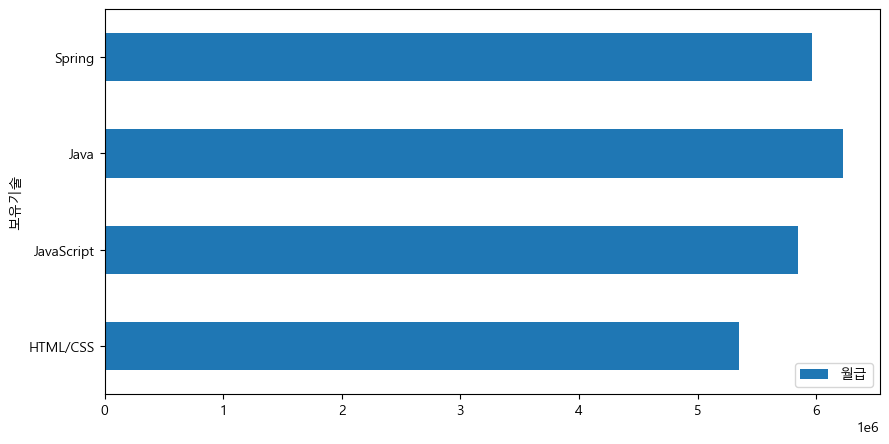

In [46]:
#프론트개발자가 다른 개발자에 비해 연봉이 낮다 -> 사실인지 확인
#프론트 : HTML/CSS, JavaScript
#백엔드 : Java, Spring
#HTML/CSS, JavaScript, Java, Spring 기술을 보유한 사람들의 평균 월급 조회 -> 월급, 보유기술 인덱싱하기

#1. 월급, 보유기술 인덱싱하기
k_salaryskill = korea_dev[["월급", "보유기술"]]

#2. groupby()로 기준 정한 후 mean()으로 평균 구하기
result = k_salaryskill.groupby("보유기술").mean()
result

#3. 인덱서로 원하는 값 찾기
front_back = result.loc[['HTML/CSS', 'JavaScript', 'Java', 'Spring']]
front_back.plot(kind='barh', figsize=(10, 5))

<Axes: xlabel='보유기술', ylabel='월급'>

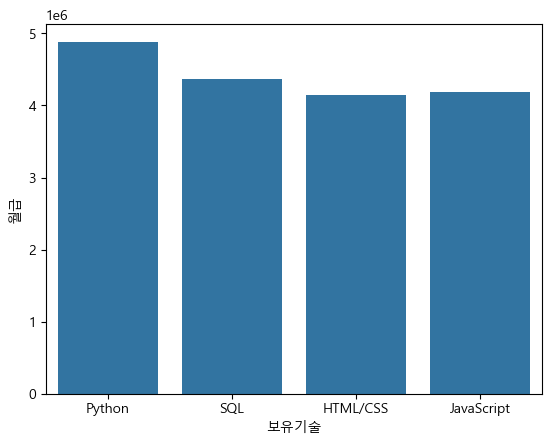

In [47]:
# 첫번째 조건 : 나이 35세 미만일것
# 두번째 조건 : 연차는 3년 이하일것
# korea_dev에서 해당 조건을 설정해서 junior_dev 변수에 담아보자

junior_dev = korea_dev[(korea_dev['나이'] == '<35') & (korea_dev['연차'] <= 3)]

#junior_dev의 보유기술별 월급 평균 구하기
junior_pay = junior_dev[["보유기술","월급"]].groupby("보유기술").mean()

#우리가 배우는 언어 기반으로 (Python, SQL, HTML/CSS, JavaScript) seaborn의 bar그래프 시각화하기
sns.barplot(data=junior_pay.loc[['Python', 'SQL', 'HTML/CSS', 'JavaScript']], x="보유기술" , y="월급")